In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.plot import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

In [29]:
# dgp = "contaminated_normal" #"contaminated_exp" #contaminated_normal
dgps = ["contaminated_normal", "contaminated_exp"]

In [30]:
df_list = []
# for name in ["cont_normal_9010_mmd", "cont_normal_9010_bas", "bdro_cont_normal_9010"]:
for name in ["kl_cont_exp_9010", "cont_exp_9010_mmd", "cont_normal_9010_mmd", "cont_normal_9010_bas", "bdro_cont_normal_9010"]:
    df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/{name}/results.csv")))
all_results_df = pd.concat(df_list)

In [31]:
all_results_df["num_observations"].unique(), all_results_df["num_posterior_samples"].unique(), all_results_df["num_likelihood_samples"].unique()

(array([20]), array([ 1, 90]), array([900,  10]))

In [32]:
dgp = dgps[0]
results_df1 = preprocess_results_df(all_results_df, dgp)
agg_df1 = get_agg_df(results_df1, ["algorithm", "dgp", "epsilon", "inference", "contamination"]) 
agg_df1.head(3)

dgp = dgps[1]
results_df2 = preprocess_results_df(all_results_df, dgp)
agg_df2 = get_agg_df(results_df2, ["algorithm", "dgp", "epsilon", "inference", "contamination"]) 
agg_df2.head(3)

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function mean at 0x7f4f40516fc0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function std at 0x7f4f40517100> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function mean at 0x7f4f40516fc0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: Futur

out_of_sample_mean  \
algorithm   dgp              epsilon inference contamination                       
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                     78.875491   
                                               0.1                     79.152800   
                                               0.2                     86.607186   

                                                              out_of_sample_var  \
algorithm   dgp              epsilon inference contamination                      
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                 10722.921092   
                                               0.1                  8719.173813   
                                               0.2                  6581.472229   

                                                              sum_of_in_group_var  \
algorithm   dgp              epsilon inference contamination                        
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                   10545.032671   
                                               0.1                    8580.632759   
                                               0.2                    6343.773919   

                                                              var_of_in_group_mean  \
algorithm   dgp              epsilon inference contamination                         
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                      177.888421   
                                               0.1                      138.541054   
                                               0.2                      237.698310   

                                                              mean_solve_time  \
algorithm   dgp              epsilon inference contamination                    
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                 280.409073   
                                               0.1                 299.975500   
                                               0.2                 287.592349   

                                                              std_solve_time  \
algorithm   dgp              epsilon inference contamination                   
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                 20.084603   
                                               0.1                 16.343233   
                                               0.2                  8.260629   

                                                              mean_sample_time  \
algorithm   dgp              epsilon inference contamination                     
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                    0.021646   
                                               0.1                    0.012110   
                                               0.2                    0.011445   

                                                              std_sample_time  
algorithm   dgp              epsilon inference contamination                   
dro_bas_mmd contaminated_exp 0.0001  npl_mmd   0.0                   0.054065  
                                               0.1                   0.001843  
                                               0.2                   0.000569

In [33]:
df_reset = agg_df1.reset_index()

# Define the filtering conditions for each algorithm
condition = (
#    (df_reset['epsilon'] > 0.3)
    ((df_reset['algorithm'] == 'dro_bas_mmd') & (df_reset['epsilon'] > 0.5)) |
    ((df_reset['algorithm'] == 'empirical_mmd') & (df_reset['epsilon'] > 0.3))
)

# Negate the condition to keep rows not matching the criteria
df_trimmed = df_reset[~condition]
df_trimmed = df_trimmed.set_index(agg_df1.index.names) 

In [34]:
df_reset = agg_df2.reset_index()

# Define the filtering conditions for each algorithm
condition = (
   ((df_reset['algorithm'] == 'dro_bas_mmd') & (df_reset['epsilon'] > 0.5)) |
   ((df_reset['algorithm'] == 'empirical_mmd') & (df_reset['epsilon'] > 0.5)) |
   ((df_reset['algorithm'] == 'kl_dro_bas') & (df_reset['epsilon'] > 1)) |
   ((df_reset['algorithm'] == 'kl_pp') & (df_reset['epsilon'] > 1))
)

# Negate the condition to keep rows not matching the criteria
df_trimmed2 = df_reset[~condition]
df_trimmed2 = df_trimmed2.set_index(agg_df2.index.names)

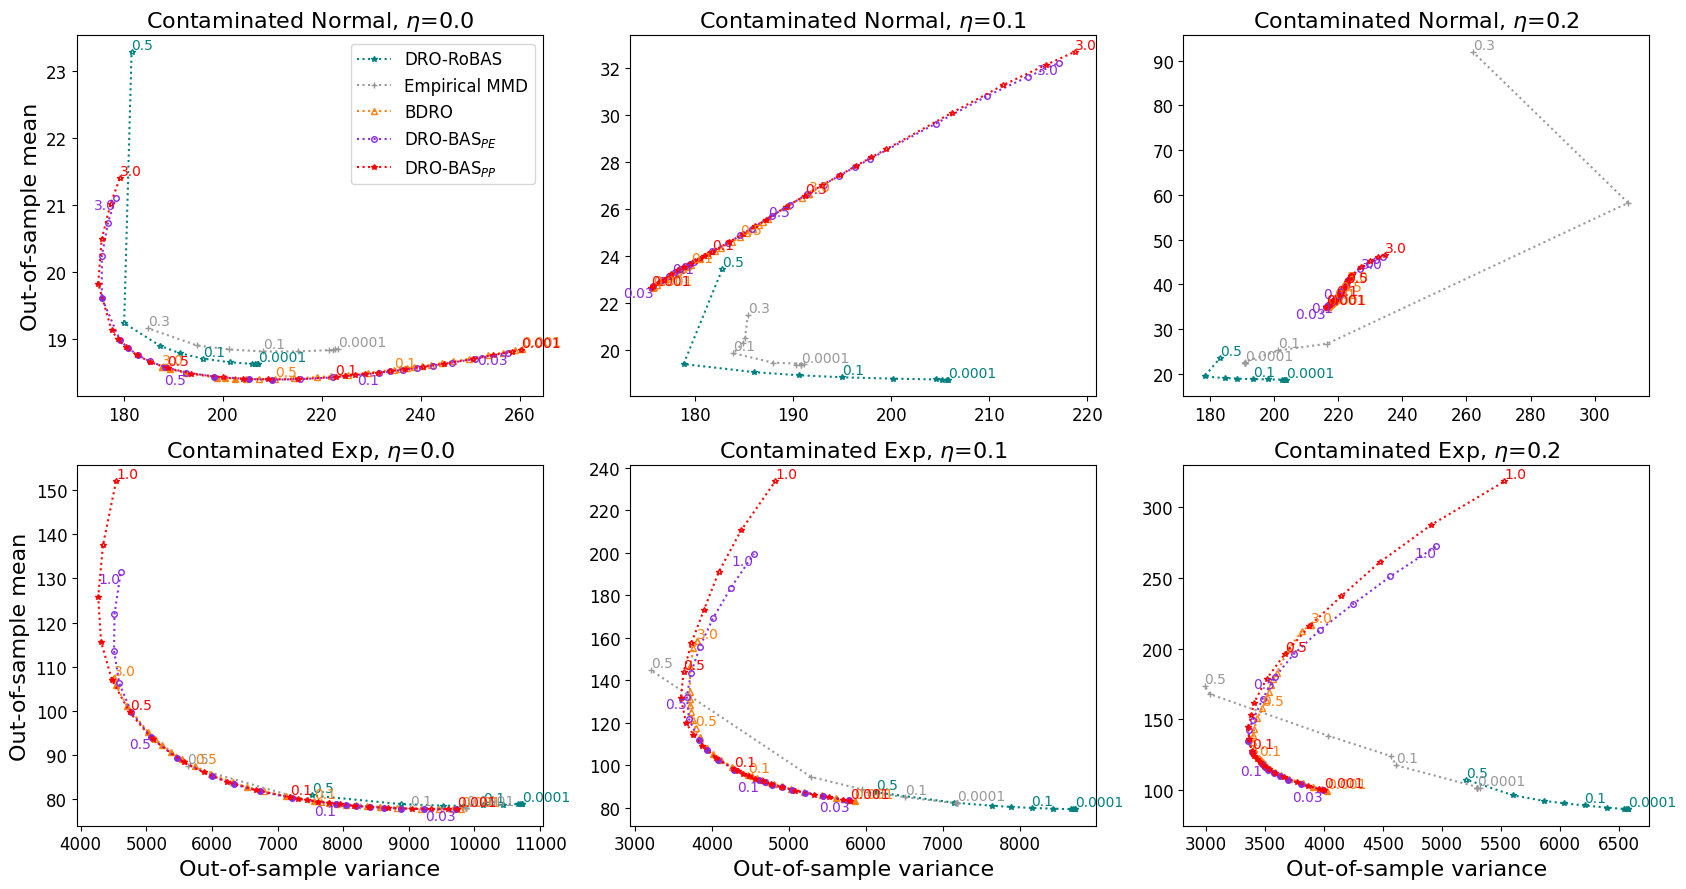

In [35]:
cont_list = agg_df1.index.get_level_values("contamination").unique().tolist()
# dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()
dgp_list = dgps

nrows = len(dgp_list)
ncols = len(cont_list)

# agg_df = agg_df.loc[:, :, :0.2]

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(17, 9))
fig.subplots_adjust(wspace=0.2)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)
total_samples = 900
for i, dgp in enumerate(dgp_list):
    if i == 0:
        df_trimmed = df_trimmed
    else:
        df_trimmed = df_trimmed2
    for j, cont in enumerate(cont_list):
        axis_df = df_trimmed.loc[:, dgp, :, :, cont]  #agg_df
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            if algorithm == 'dro_bas_mmd':
                inference = "npl_mmd"
            elif algorithm in ['kl_bdro', 'kl_dro_bas', 'kl_pp']:
                inference = "bayes"
            else:
                inference = "empirical"
            df = axis_df.loc[algorithm, :, inference]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i,j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[i,j].set_ylabel("Out-of-sample mean", fontsize=16)
        axes[i,j].set_title(f"{NiceNameDGP[dgp]}," + " $\eta$" + f"={cont_list[j]}", fontsize=16) 
        axes[i,j].tick_params(axis='both', which='major', labelsize=12)
        if i == 1:
            axes[i,j].set_xlabel("Out-of-sample variance", fontsize=16)
        if j == 0 and i == 0:
            axes[i,j].legend(fontsize=12)
plt.tight_layout()

In [36]:
solve_time_df = get_agg_df(results_df, ["algorithm", "contamination"])
solve_time_df = solve_time_df.round(decimals=2)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df["str_solve_time"].unstack(level="algorithm").to_latex())

NameError: name 'results_df' is not defined

In [133]:
print(solve_time_df["str_sample_time"].unstack(level="algorithm").to_latex())

\begin{tabular}{lllll}
\toprule
algorithm & dro_bas_mmd & empirical_mmd & kl_bdro & kl_dro_bas \\
contamination &  &  &  &  \\
\midrule
0.000000 & 37.56 (4.04) & 0.0 (0.0) & 0.1 (0.01) & 0.0 (0.0) \\
0.100000 & 37.35 (3.44) & 0.0 (0.0) & 0.1 (0.01) & 0.0 (0.0) \\
0.200000 & 37.33 (3.5) & 0.0 (0.0) & 0.1 (0.01) & 0.0 (0.0) \\
\bottomrule
\end{tabular}



In [128]:
from mis_dro.main import POSTERIOR_GB_COLS

npl_samples_dir = Path("/dcs/large/u1508153/misdro/npl_samples_newsvendor_1d")
# npl_df = results_df.loc[results_df["inference"] == "npl_mmd"]
settings_df = pd.read_csv(npl_samples_dir / "npl_settings.csv")

merged_df = results_df.merge(settings_df, how="left", on=POSTERIOR_GB_COLS)
merged_df["npl_uuid"]

KeyError: 'npl_uuid'

In [ ]:
times_df = pd.concat([pd.read_csv(npl_samples_dir / npl_uuid / f"npl_times_{npl_uuid}.csv") for npl_uuid in settings_df["npl_uuid"]])
times_df

,replication,npl_uuid,posterior_time
0,0,fdaf7c1c-7bbc-475f-997c-0471abf9470b,78.809292
1,1,fdaf7c1c-7bbc-475f-997c-0471abf9470b,76.005982
2,2,fdaf7c1c-7bbc-475f-997c-0471abf9470b,38.591716
3,3,fdaf7c1c-7bbc-475f-997c-0471abf9470b,38.180791
4,4,fdaf7c1c-7bbc-475f-997c-0471abf9470b,37.782680
...,...,...,...
195,195,eddec53a-e24e-4087-8ec3-381552862650,36.656614
196,196,eddec53a-e24e-4087-8ec3-381552862650,36.160709
197,197,eddec53a-e24e-4087-8ec3-381552862650,36.156451
198,198,eddec53a-e24e-4087-8ec3-381552862650,36.421258


In [ ]:
# merged_df.merge(times_df, on=["npl_uuid", "replication"], suffixes=('_drop', '')).drop("posterior_time_drop", axis="columns")
df_3 = merged_df.merge(times_df, on=["npl_uuid", "replication"], how="left", suffixes=('', '_drop'))
df_3[["posterior_time", "posterior_time_drop"]]

,posterior_time,posterior_time_drop
0,0.003113,78.539420
1,0.004506,61.253829
2,0.004077,37.698871
3,0.002346,37.581497
4,0.004258,37.188705
...,...,...
23995,0.000213,NaN
23996,0.000226,NaN
23997,0.000208,NaN
23998,0.000222,NaN


In [ ]:
df_3.loc[~(df_3['posterior_time_drop'].isna()), 'posterior_time'] = df_3['posterior_time_drop']
df_3 = df_3.drop("posterior_time_drop", axis=1)


,posterior_time,posterior_time_drop
0,78.539420,78.539420
1,61.253829,61.253829
2,37.698871,37.698871
3,37.581497,37.581497
4,37.188705,37.188705
...,...,...
23995,0.000213,NaN
23996,0.000226,NaN
23997,0.000208,NaN
23998,0.000222,NaN
